<img src="https://devra.ai/analyst/notebook/6615/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">  <div style="font-size:150%; color:#FEE100"><b>Data Engineering AI Pipelines Analysis Notebook</b></div>  <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>It is often said that true insights arise when data is allowed to tell its own story. In this notebook, we unravel the secrets behind data engineering AI pipelines. If you find the analysis useful, please consider upvoting it.

## Table of Contents

- [Introduction](#Introduction)
- [Data Loading and Overview](#Data-Loading-and-Overview)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Predictive Modeling](#Predictive-Modeling)
- [Conclusions and Future Work](#Conclusions-and-Future-Work)

## Introduction

Welcome to our analysis notebook for the Data Engineering AI Pipelines dataset. Our aim is to explore a range of data engineering tools and techniques from data importing and cleaning through to exploratory analysis and predictive modeling. We use various visualization methods such as heatmaps, pair plots, histograms, and more to derive insights and, if possible, build a predictor.

In [1]:
# Importing the necessary libraries and suppressing warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # Ensure matplotlib uses 'Agg'
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switching backend if needed

# For inline plotting in notebooks
%matplotlib inline

from pathlib import Path

# Set seaborn style for plots
sns.set(style='whitegrid')

# Helper function to resolve data file paths dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets')
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Imports and setup complete.')

Imports and setup complete.


In [2]:
# Data Loading and Overview
# Dynamically resolve the file paths for the dataset and metadata
data_file = resolve_data_file(file_name='data_engineering_ai_pipelines.csv', suffixes=['.csv'])
metadata_file = resolve_data_file(file_name='dataset-metadata.json.metadata.json', suffixes=['.json'])

# Load the dataset
df = pd.read_csv(data_file, encoding='ascii', delimiter=',')

# Load the metadata (if needed for further context)
with open(metadata_file, 'r') as f:
    metadata = pd.read_json(f.read(), typ='series')

# Overview of the dataframe
print('Dataset Shape:', df.shape)
print('Dataset Columns:', df.columns.tolist())
df.head()

Dataset Shape: (6000, 14)
Dataset Columns: ['record_id', 'submission_date', 'job_role', 'work_location', 'years_of_experience', 'primary_cloud', 'orchestrator', 'data_warehouse', 'vector_database', 'has_production_rag', 'daily_volume_gb', 'avg_pipeline_duration_min', 'monthly_failure_rate_pct', 'salary_usd']


,record_id,submission_date,job_role,work_location,years_of_experience,primary_cloud,orchestrator,data_warehouse,vector_database,has_production_rag,daily_volume_gb,avg_pipeline_duration_min,monthly_failure_rate_pct,salary_usd
0,PIPE-100000,2025-11-12,Senior Data Engineer,France,10,Google Cloud,Prefect,Snowflake,Pinecone,True,24,15,4.73,169209
1,PIPE-100001,2025-03-30,Data Engineer,United Arab Emirates,8,AWS,Apache Airflow,Redshift,Pinecone,True,45,33,2.08,150713
2,PIPE-100002,2024-08-04,Analytics Engineer,Remote (Worldwide),6,AWS,Apache Airflow,Snowflake,Qdrant,True,569,29,10.73,107733
3,PIPE-100003,2024-02-10,Senior Data Engineer,United Kingdom,1,AWS,Dagster,PostgreSQL,Pinecone,True,41,6,8.91,83866
4,PIPE-100004,2024-01-15,AI Platform Engineer,Remote (Worldwide),7,AWS,Apache Airflow,Redshift,ChromaDB,True,1833,9,3.20,156899


## Data Cleaning and Preprocessing

In this section, we fix the data types and handle missing values if they exist. One common issue that many notebook creators may face is incorrect date parsing. Here, we convert the 'submission_date' column into a datetime type, ensuring that any related errors are managed appropriately.

In [3]:
# Data Cleaning and Preprocessing
print('Preprocessing dataset...')

# Converting submission_date to datetime. Since the data type was string, we attempt conversion.
try:
    df['submission_date'] = pd.to_datetime(df['submission_date'], errors='coerce')
    print('Converted submission_date to datetime')
except Exception as e:
    print('Error converting submission_date:', e)

# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# For simplicity, we can drop rows with missing critical values or decide on another strategy
df.dropna(inplace=True)
print('After dropping missing values, dataset shape:', df.shape)

Preprocessing dataset...
Converted submission_date to datetime
Missing values in each column:
record_id                       0
submission_date                 0
job_role                        0
work_location                   0
years_of_experience             0
primary_cloud                   0
orchestrator                    0
data_warehouse                  0
vector_database              1543
has_production_rag              0
daily_volume_gb                 0
avg_pipeline_duration_min       0
monthly_failure_rate_pct        0
salary_usd                      0
dtype: int64
After dropping missing values, dataset shape: (4457, 14)


## Exploratory Data Analysis

Here we investigate the dataset using several visualizations. The data contains a mix of categorical and numerical features. We extract the numerical columns for correlation analysis, use histograms to assess the distribution of key variables, and employ various plots to gain insights into relationships in the data.

Generating visualizations...


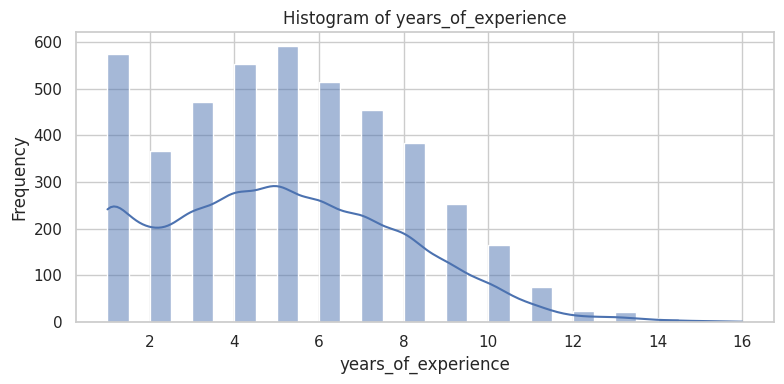

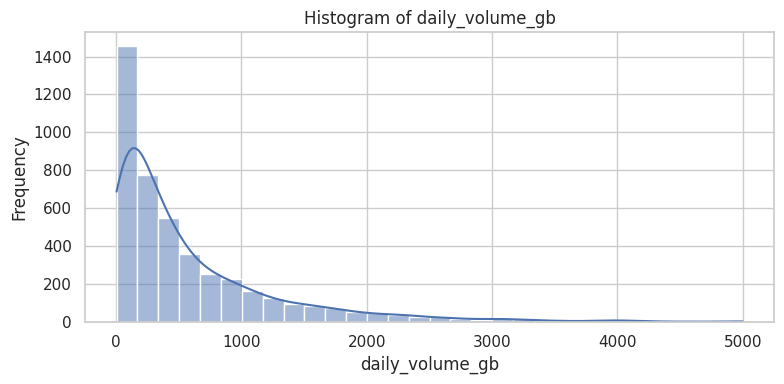

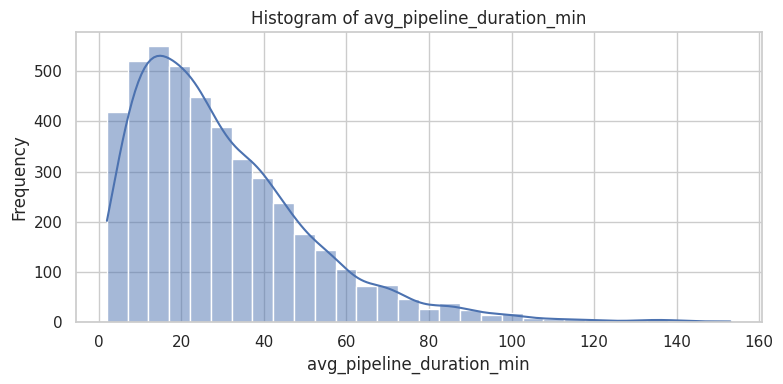

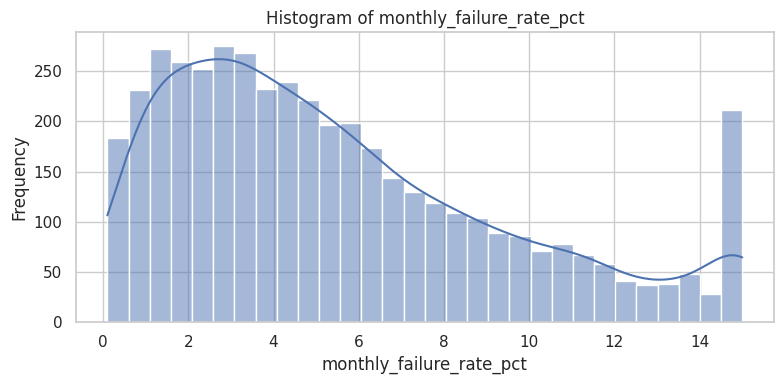

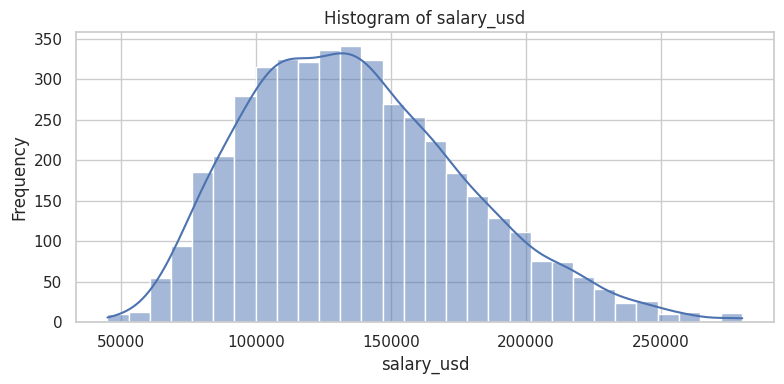

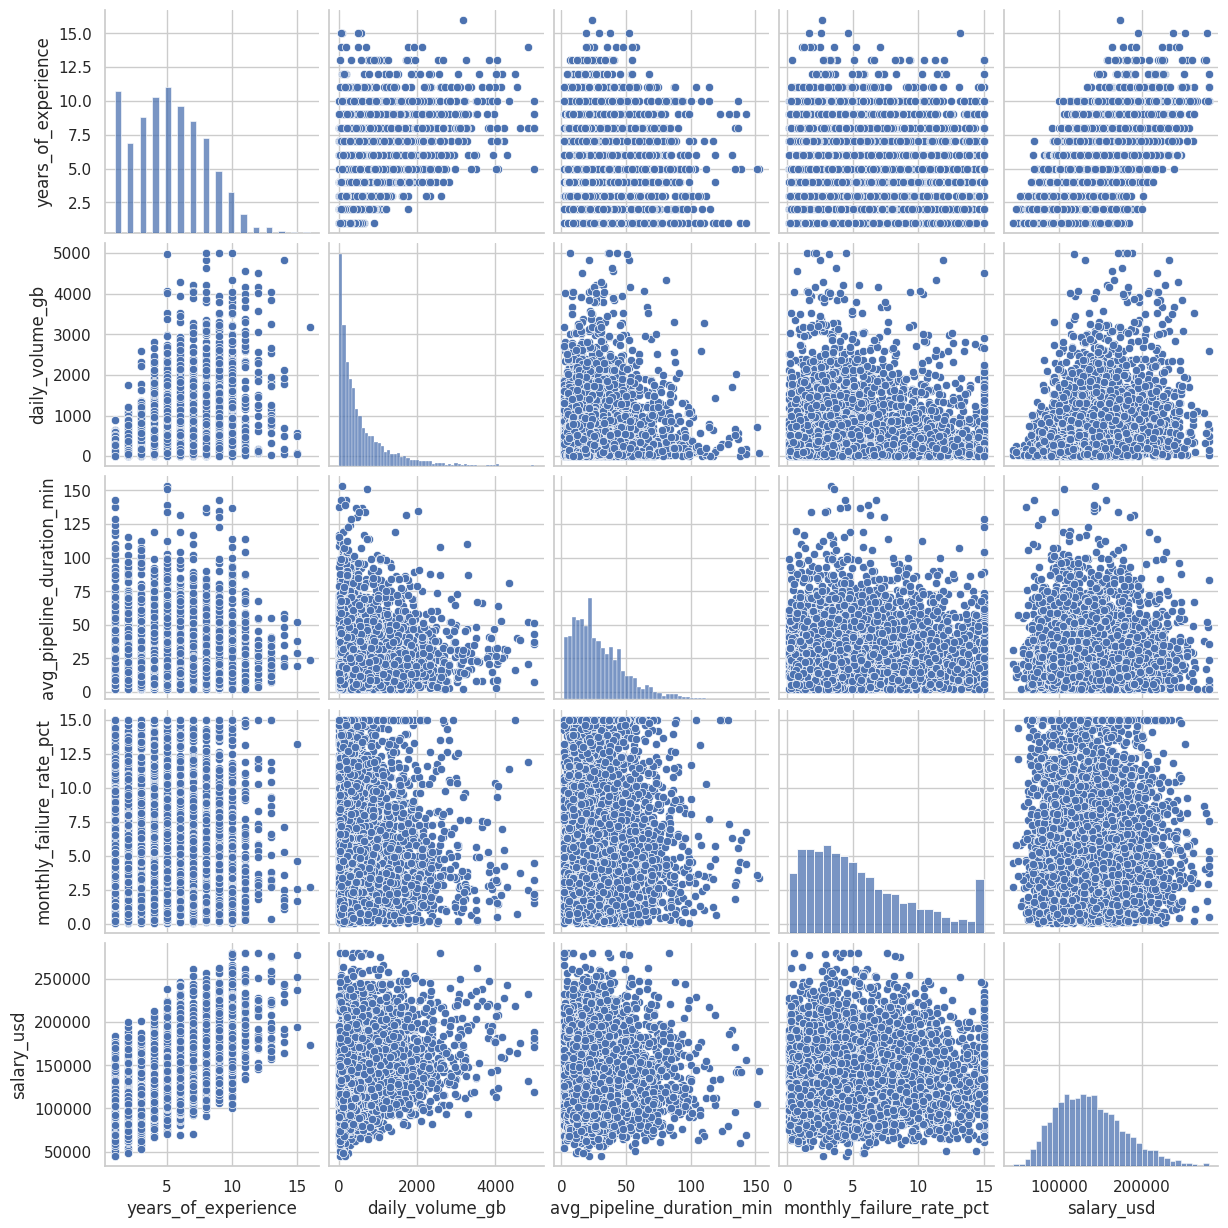

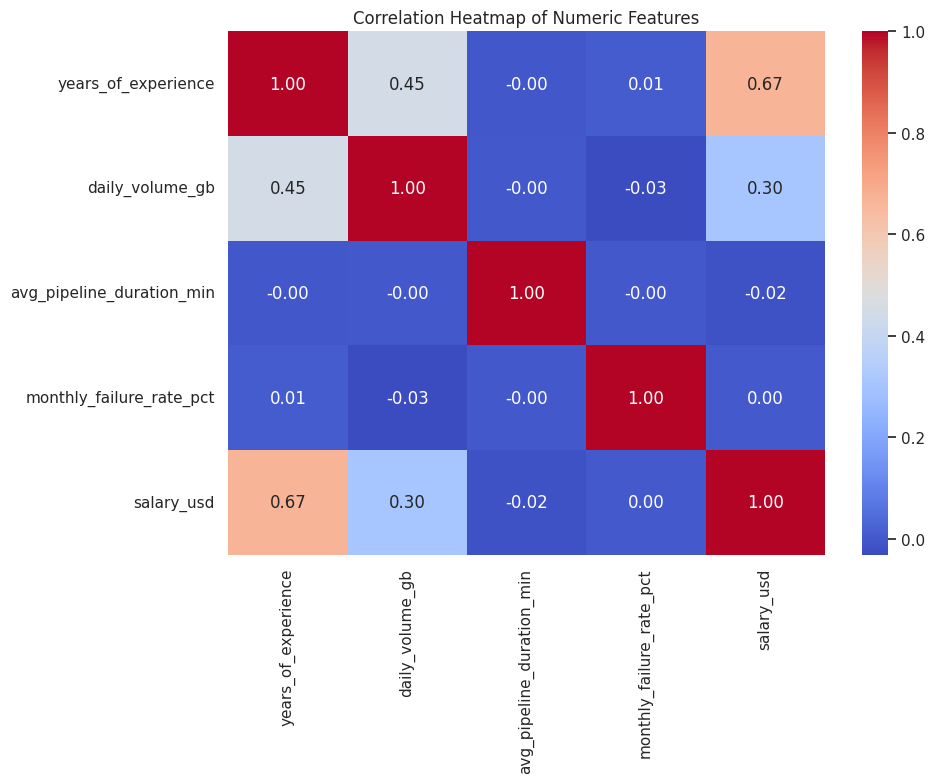

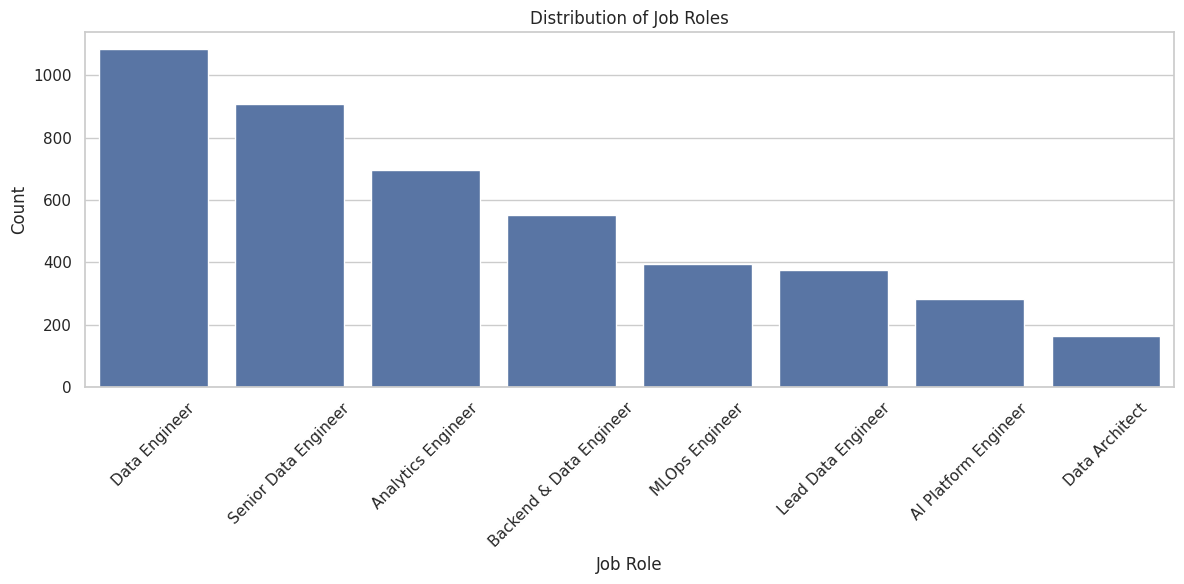

In [4]:
# Exploratory Data Analysis
print('Generating visualizations...')

## Histogram for key numeric features
numeric_columns = ['years_of_experience', 'daily_volume_gb', 'avg_pipeline_duration_min', 'monthly_failure_rate_pct', 'salary_usd']
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## Pair Plot for numeric features
sns.pairplot(df[numeric_columns])
plt.show()

## If there are four or more numeric columns, perform a heatmap for correlation
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

## Count plot for a categorical variable, e.g., job_role
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job_role', order=df['job_role'].value_counts().index)
plt.title('Distribution of Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

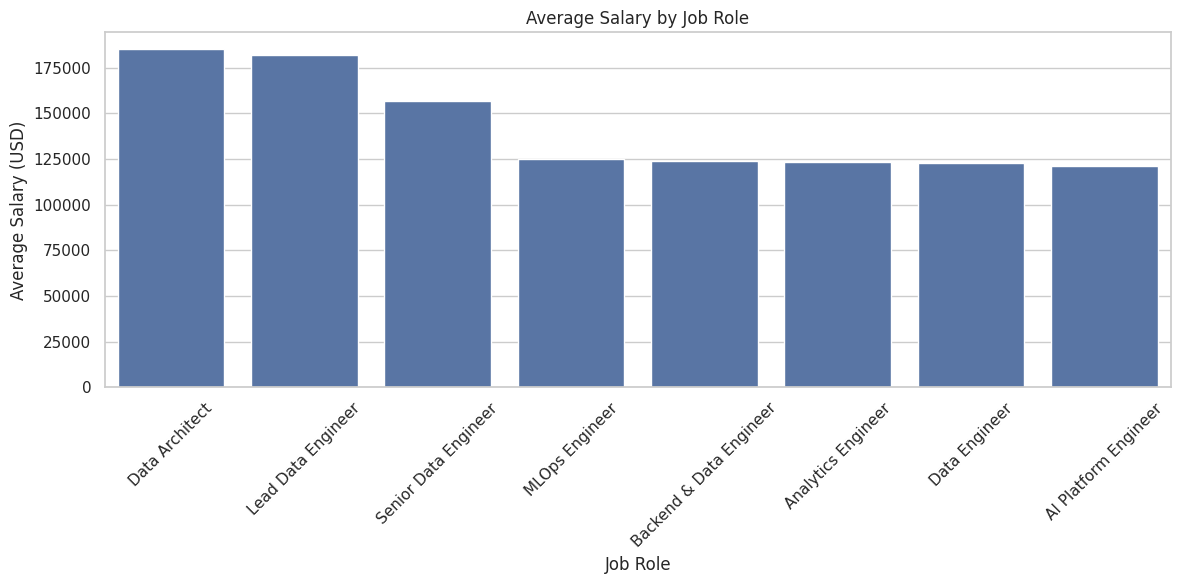

In [5]:
# Grouped Bar Plot: Average salary by job_role
plt.figure(figsize=(12, 6))
avg_salary = df.groupby('job_role')['salary_usd'].mean().reset_index()
sns.barplot(data=avg_salary, x='job_role', y='salary_usd', order=avg_salary.sort_values('salary_usd', ascending=False)['job_role'])
plt.title('Average Salary by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Predictive Modeling

This section builds a simple predictive model to estimate the annual salary (salary_usd) based on available numeric features. Using a Linear Regression model, we assess how well features such as years of experience, daily volume, pipeline duration, and monthly failure rate predict the salary. We use the R² score as a metric for prediction accuracy.

Linear Regression R^2 Score: 0.43


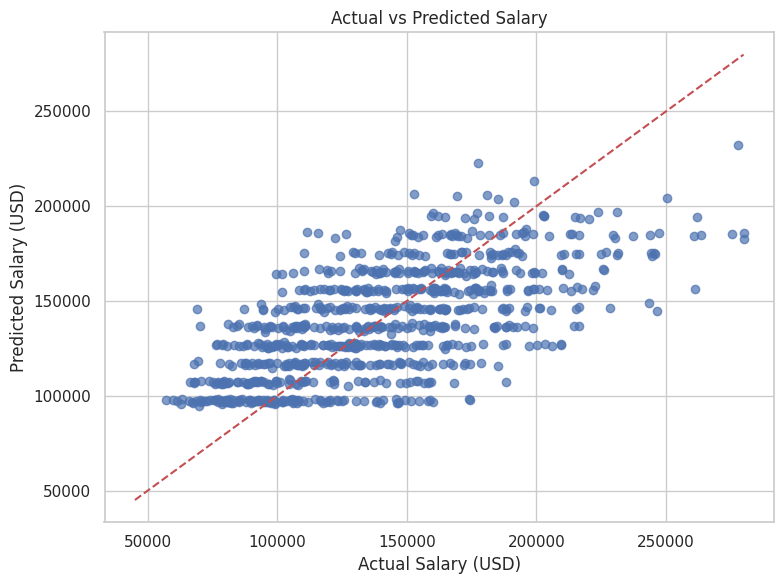

In [6]:
# Predictive Modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Select features and target variable. We use only the numeric features.
features = ['years_of_experience', 'daily_volume_gb', 'avg_pipeline_duration_min', 'monthly_failure_rate_pct']
target = 'salary_usd'

# Split the data into training and testing sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using R^2 score
score = r2_score(y_test, y_pred)
print(f'Linear Regression R^2 Score: {score:.2f}')

# Optional: Plotting the true vs predicted salaries
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title('Actual vs Predicted Salary')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # line of perfect fit
plt.tight_layout()
plt.show()

## Conclusions and Future Work

This notebook explored the Data Engineering AI Pipelines dataset from data loading to predictive modeling. We applied a variety of visualization techniques to extract insights from the data. In building our predictor, we employed a straightforward linear regression model, achieving a moderate R² score. 

The merits of this approach include the simplicity and interpretability of linear regression, as well as the quick insights gained through diverse visualizations. Future analyses could expand upon this work by:

- Incorporating more complex models or cross-validation techniques to enhance prediction performance.
- Integrating categorical encoding methods for non-numeric features for richer predictive models.
- Conducting time series analysis on the submission_date to identify trends or seasonal patterns.

Thank you for exploring this notebook. If you found these insights useful, please consider upvoting.